# Notebook 2: N-gram Analysis — Function Sequences and Power Spikes

This notebook demonstrates our method for attributing power spikes to *sequences* of library
function calls (n-grams).  For each benchmark in `app-traces/`:

1. Extract the ordered sequence of BLAS/solver entry-point calls per MPI rank
2. Build 2-gram (bigram) and 3-gram (trigram) statistics paired with the instantaneous GPU power
   during each call window
3. Visualize which function sequences are most predictive of high power draw


In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
})
BG = '#fafafa'

# BLAS / solver entry points to track (name without argument list)
BLAS_ENTRY_POINTS = {
    'rocblas_dgemm', 'rocblas_dtrsm', 'rocblas_dgemv', 'rocblas_dtrsv',
    'rocblas_dsyrk', 'rocblas_dtrmm', 'rocblas_dger', 'rocblas_dscal',
    'rocblas_daxpy', 'rocblas_dcopy', 'rocblas_idamax',
    'rocblas_sgemm', 'rocblas_sgemv', 'rocblas_strsm',
    'rocblas_gemm_ex', 'rocblas_gemm_strided_batched_ex',
    'rocsolver_dgetrf', 'rocsolver_dgetrs',
    'rocsolver_strtri', 'rocsolver_dtrtri',
}

# Per-function color for consistent legend across plots
FUNC_BASE_COLORS = [
    '#2d6a4f', '#e07a3a', '#9b5de5', '#4cc9f0', '#e63946',
    '#457b9d', '#f4a261', '#2a9d8f', '#e9c46a', '#264653',
    '#a8dadc', '#6d6875', '#b5838d', '#ffb703', '#023047',
    '#8338ec', '#fb5607', '#ff006e', '#3a86ff', '#06d6a0',
]

def func_color_map(names):
    return {n: FUNC_BASE_COLORS[i % len(FUNC_BASE_COLORS)] for i, n in enumerate(sorted(names))}


## 1. Data Discovery

In [2]:
APP_TRACES_ROOT = Path("./app-traces")

def discover_benchmarks(root: Path) -> dict:
    found = {}
    for bench in sorted(root.iterdir()):
        if not bench.is_dir(): continue
        for trial in sorted(bench.iterdir()):
            if not trial.is_dir(): continue
            csvs = list(trial.glob("MPI Rank*_Master_thread_callgraph.csv"))
            if csvs:
                found[bench.name] = trial
                break
        else:
            print(f"  [no data yet] {bench.name}")
    print(f"Discovered {len(found)} benchmark(s): {list(found.keys())}")
    return found

BENCHMARKS = discover_benchmarks(APP_TRACES_ROOT)


  [no data yet] HPG-MxP-Full
  [no data yet] LSMS
  [no data yet] QMCPACK
Discovered 2 benchmark(s): ['HPL', 'HPL-MxP']


## 2. Load BLAS Calls and Power

For every MPI rank in every benchmark: extract the ordered sequence of BLAS/solver calls and correlate each call with instantaneous GPU power during its execution window.

In [3]:
def short_blas(name: str) -> str:
    """Strip argument list and template params, return bare function name."""
    p = name.find('(')
    base = name[:p] if p != -1 else name
    a = base.find('<')
    return (base[:a] if a != -1 else base).strip()

def load_power_series(metrics_path: Path) -> tuple:
    """Return (times, combined_power_W) from energy counter CSVs."""
    dm = pd.read_csv(metrics_path)
    series = []
    for dev in [0, 2, 4, 6]:
        sub = dm[dm['Metric Name'] == f'A2rocm_smi:::energy_count:device={dev}'].sort_values('Time')
        if len(sub) < 2: continue
        t  = sub['Time'].values
        e  = sub['Value'].values * 1e-6
        dt = np.diff(t); de = np.diff(e)
        p  = np.where((dt > 0) & (de >= 0), de / dt, 0.0)
        series.append((t[1:], p))
    if not series:
        return np.array([]), np.array([])
    min_len = min(len(pt) for pt, _ in series)
    t_ref   = series[0][0][:min_len]
    total_p = sum(np.interp(t_ref, pt, pv) for pt, pv in series)
    return t_ref, total_p

def mean_power_in_window(t0: float, t1: float,
                          power_t: np.ndarray, power_v: np.ndarray) -> float:
    mask = (power_t >= t0) & (power_t <= t1)
    p = power_v[mask]
    return float(p.mean()) if len(p) > 0 else np.nan

def peak_power_in_window(t0: float, t1: float,
                          power_t: np.ndarray, power_v: np.ndarray) -> float:
    mask = (power_t >= t0) & (power_t <= t1)
    p = power_v[mask]
    return float(p.max()) if len(p) > 0 else np.nan

def load_blas_calls_for_bench(bench_name: str, trial_path: Path) -> pd.DataFrame:
    """Load all BLAS entry-point calls for every rank in a benchmark."""
    parts = []
    rank_files = sorted(trial_path.glob("MPI Rank*_Master_thread_callgraph.csv"))
    for cg_path in rank_files:
        m = re.match(r"MPI Rank (\d+)_", cg_path.name)
        if not m: continue
        rank_id = int(m.group(1))
        m_path  = trial_path / f"MPI Rank {rank_id}_metrics.csv"

        df = pd.read_csv(cg_path, usecols=['Name', 'Start Time', 'End Time'])
        df['Short']    = df['Name'].apply(short_blas)
        df = df[df['Short'].isin(BLAS_ENTRY_POINTS)].copy()
        if df.empty: continue
        df['Rank']     = rank_id
        df['Bench']    = bench_name
        df['Duration'] = df['End Time'] - df['Start Time']

        # Add power statistics if metrics exist
        if m_path.exists():
            power_t, power_v = load_power_series(m_path)
            if len(power_t) > 0:
                df['PowerMean'] = [mean_power_in_window(r['Start Time'], r['End Time'],
                                                         power_t, power_v)
                                   for _, r in df.iterrows()]
                df['PowerPeak'] = [peak_power_in_window(r['Start Time'], r['End Time'],
                                                         power_t, power_v)
                                   for _, r in df.iterrows()]
            else:
                df['PowerMean'] = np.nan
                df['PowerPeak'] = np.nan
        else:
            df['PowerMean'] = np.nan
            df['PowerPeak'] = np.nan

        parts.append(df)
        print(f"  {bench_name} rank {rank_id}: {len(df):,} BLAS calls")

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

all_calls = {}
for bench_name, trial_path in BENCHMARKS.items():
    print(f"\nLoading {bench_name}...")
    df = load_blas_calls_for_bench(bench_name, trial_path)
    if not df.empty:
        all_calls[bench_name] = df

combined = pd.concat(all_calls.values(), ignore_index=True) if all_calls else pd.DataFrame()
print(f"\nTotal BLAS calls across all benchmarks: {len(combined):,}")



Loading HPL...
  HPL rank 0: 5,534 BLAS calls
  HPL rank 1: 5,522 BLAS calls
  HPL rank 2: 5,524 BLAS calls
  HPL rank 3: 5,526 BLAS calls
  HPL rank 4: 5,528 BLAS calls
  HPL rank 5: 5,530 BLAS calls
  HPL rank 6: 5,532 BLAS calls
  HPL rank 7: 5,534 BLAS calls

Loading HPL-MxP...

Total BLAS calls across all benchmarks: 44,230


## 3. Build N-gram Sequences

For each MPI rank, sort calls by start time and build consecutive 2- and 3-call sequences.

In [4]:
def build_ngrams(calls_df: pd.DataFrame, n: int) -> pd.DataFrame:
    """Build n-gram records from time-ordered call sequences, per (Bench, Rank)."""
    records = []
    for (bench, rank), grp in calls_df.groupby(['Bench', 'Rank']):
        seq = grp.sort_values('Start Time').reset_index(drop=True)
        for i in range(len(seq) - n + 1):
            window = seq.iloc[i:i+n]
            gram   = ' → '.join(window['Short'].tolist())
            records.append({
                'Bench':     bench,
                'Rank':      rank,
                'NGram':     gram,
                'Start':     window.iloc[0]['Start Time'],
                'End':       window.iloc[-1]['End Time'],
                'Duration':  window.iloc[-1]['End Time'] - window.iloc[0]['Start Time'],
                'PowerMean': window['PowerMean'].mean(),
                'PowerPeak': window['PowerPeak'].max(),
                'First':     window.iloc[0]['Short'],
                'Last':      window.iloc[-1]['Short'],
            })
    return pd.DataFrame(records)

if not combined.empty:
    bigrams  = build_ngrams(combined, 2)
    trigrams = build_ngrams(combined, 3)
    print(f"Bigrams:  {len(bigrams):,}  ({bigrams['NGram'].nunique()} unique)")
    print(f"Trigrams: {len(trigrams):,}  ({trigrams['NGram'].nunique()} unique)")
else:
    bigrams = trigrams = pd.DataFrame()
    print("No call data available.")


Bigrams:  44,222  (8 unique)
Trigrams: 44,214  (12 unique)


## Figure 1: Function Transition Heatmap

For each pair (A → B), how often does function A immediately precede function B?  Cell color = call count (log scale).

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_34679/1169277562.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.set_ticklabels([f'{int(np.expm1(t)):.0f}' for t in cb.get_ticks()])
/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_34679/1169277562.py:36: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Times New Roman.
  fig.tight_layout()
/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_34679/1169277562.py:36: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Times New Roman.
  fig.tight_layout()
/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_34679/1169277562.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Times New Roman.
  fig.savefig('fig1_ngram_transition_heatmap.pdf', facecolor=BG, bbox_inches='tight')
/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_34679/1169277562.py:37: User

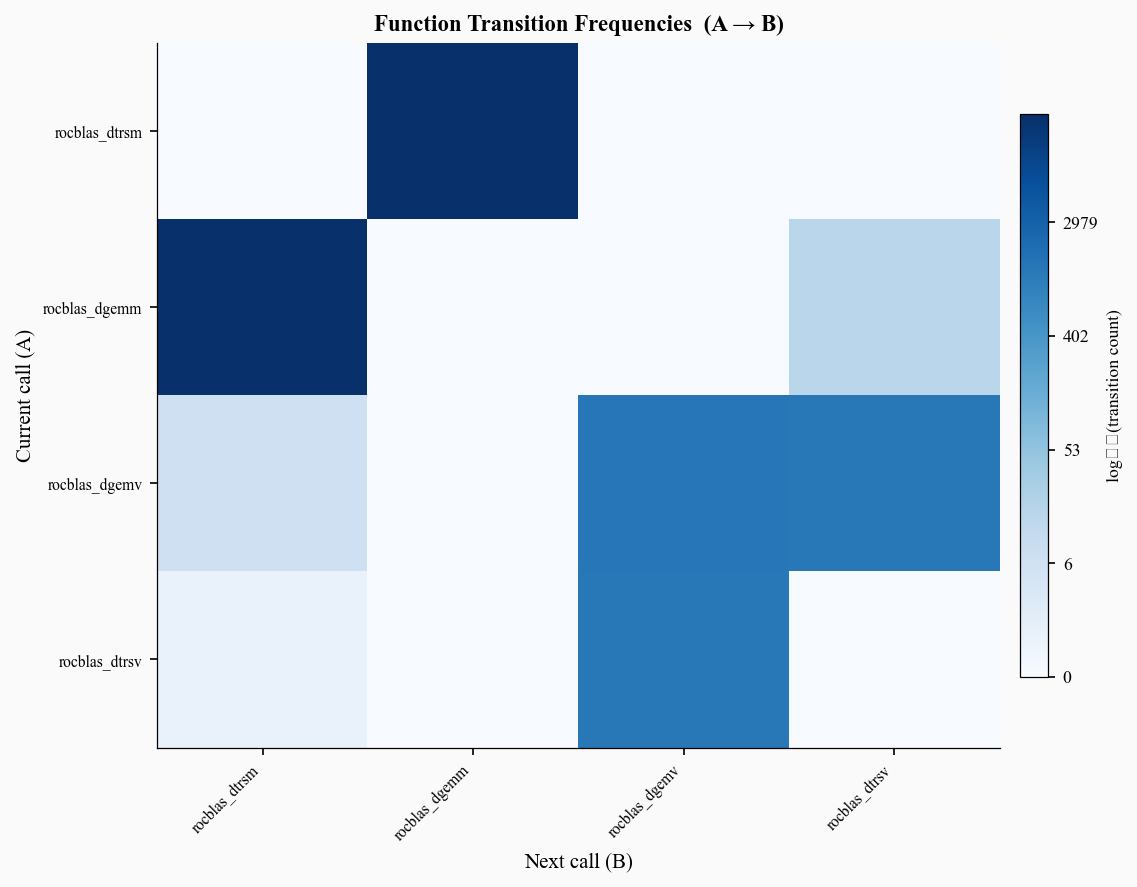

In [5]:
if not combined.empty:
    # Build (from, to) counts across all benchmarks
    trans_rows = []
    for (bench, rank), grp in combined.groupby(['Bench', 'Rank']):
        seq = grp.sort_values('Start Time')['Short'].tolist()
        for a, b in zip(seq[:-1], seq[1:]):
            trans_rows.append({'From': a, 'To': b})
    trans = pd.DataFrame(trans_rows)

    # Keep functions that appear in at least 5 transitions
    freq   = trans['From'].value_counts()
    common = freq[freq >= 5].index.tolist()
    trans  = trans[trans['From'].isin(common) & trans['To'].isin(common)]

    mat = (trans.groupby(['From', 'To']).size()
               .unstack(fill_value=0)
               .reindex(index=common, columns=common, fill_value=0))

    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(common)),
                                    max(6, 0.55 * len(common))),
                            facecolor=BG)
    ax.set_facecolor(BG)
    im = ax.imshow(np.log1p(mat.values), aspect='auto', cmap='Blues')
    cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label('log₁₊(transition count)', fontsize=8.5)
    cb.set_ticklabels([f'{int(np.expm1(t)):.0f}' for t in cb.get_ticks()])

    ax.set_xticks(range(len(common)))
    ax.set_xticklabels(common, rotation=45, ha='right', fontsize=7.5)
    ax.set_yticks(range(len(common)))
    ax.set_yticklabels(common, fontsize=7.5)
    ax.set_xlabel('Next call (B)')
    ax.set_ylabel('Current call (A)')
    ax.set_title('Function Transition Frequencies  (A → B)', fontweight='bold')

    fig.tight_layout()
    fig.savefig('fig1_ngram_transition_heatmap.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 2: Top Bigrams by Mean Power

Which 2-call sequences are most consistently associated with high GPU power draw?

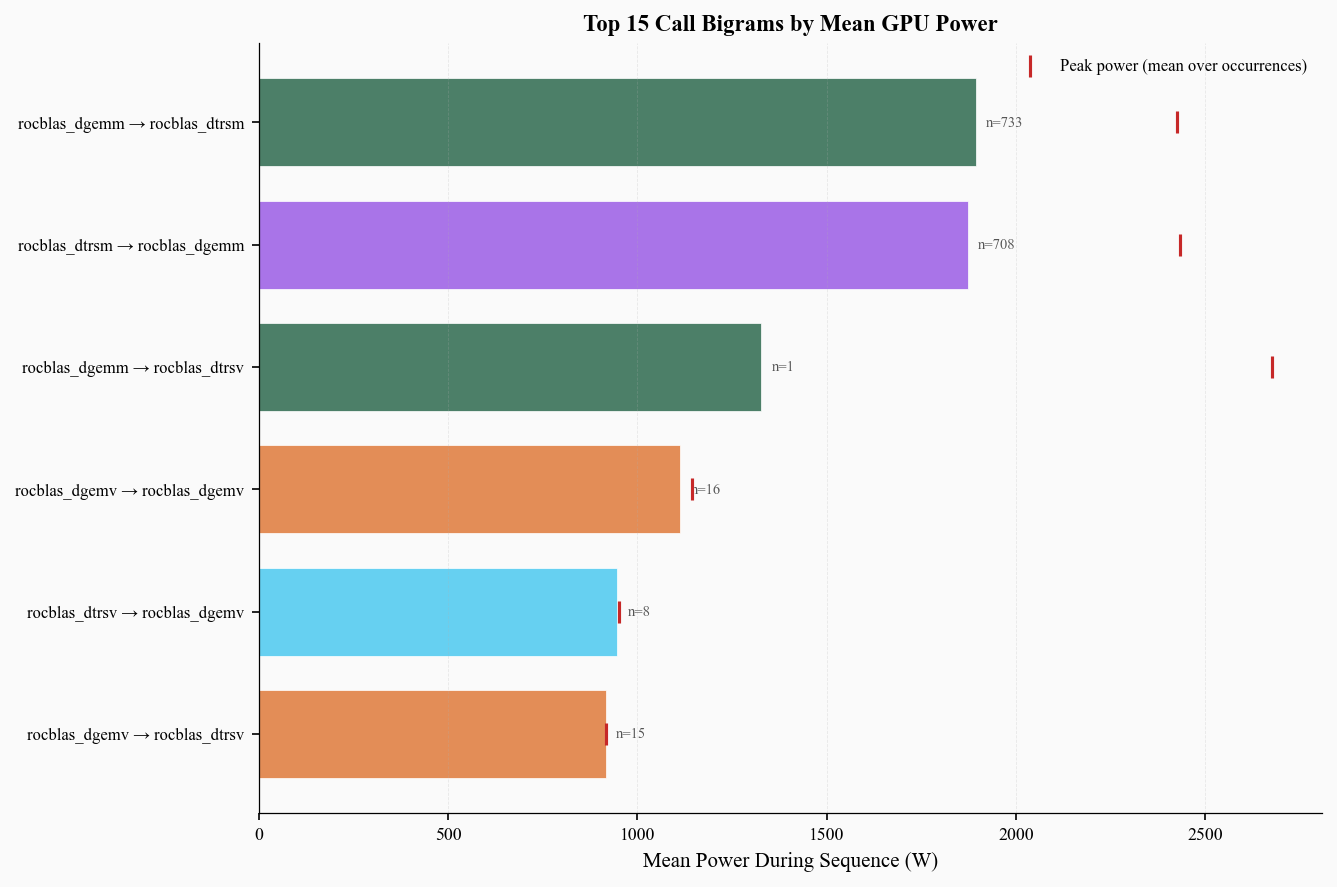

In [6]:
if not bigrams.empty:
    bg_stats = (bigrams.dropna(subset=['PowerMean'])
                       .groupby('NGram')
                       .agg(mean_power=('PowerMean', 'mean'),
                            peak_power=('PowerPeak', 'mean'),
                            count=('NGram', 'size'))
                       .reset_index()
                       .sort_values('mean_power', ascending=False)
                       .head(15))

    fcolors = func_color_map(combined['Short'].unique())

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    ax.set_facecolor(BG)

    # Color bars by the first function in the bigram
    colors = [fcolors.get(row['NGram'].split(' → ')[0], '#888')
              for _, row in bg_stats.iterrows()]

    bars = ax.barh(range(len(bg_stats)), bg_stats['mean_power'].values,
                   color=colors, edgecolor='white', linewidth=0.4, height=0.72, alpha=0.85)
    # Peak power as error-bar style marker
    ax.scatter(bg_stats['peak_power'].values, range(len(bg_stats)),
               marker='|', s=120, color='#C62828', zorder=4,
               linewidths=1.5, label='Peak power (mean over occurrences)')

    ax.set_yticks(range(len(bg_stats)))
    ax.set_yticklabels(bg_stats['NGram'].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Mean Power During Sequence (W)')
    ax.set_title('Top 15 Call Bigrams by Mean GPU Power', fontweight='bold')
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis='x', alpha=0.25, linestyle='--')

    # Count annotation
    for i, (_, row) in enumerate(bg_stats.iterrows()):
        ax.text(row['mean_power'] + ax.get_xlim()[1] * 0.01, i,
                f"n={row['count']:,}", va='center', fontsize=7, color='#555')

    fig.tight_layout()
    fig.savefig('fig2_bigram_power.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 3: Per-Function Power Distribution

Violin + box plots showing the spread of GPU power during each BLAS entry-point call.  
Wide distributions indicate context-dependent power (e.g., varies with problem size or calling context).

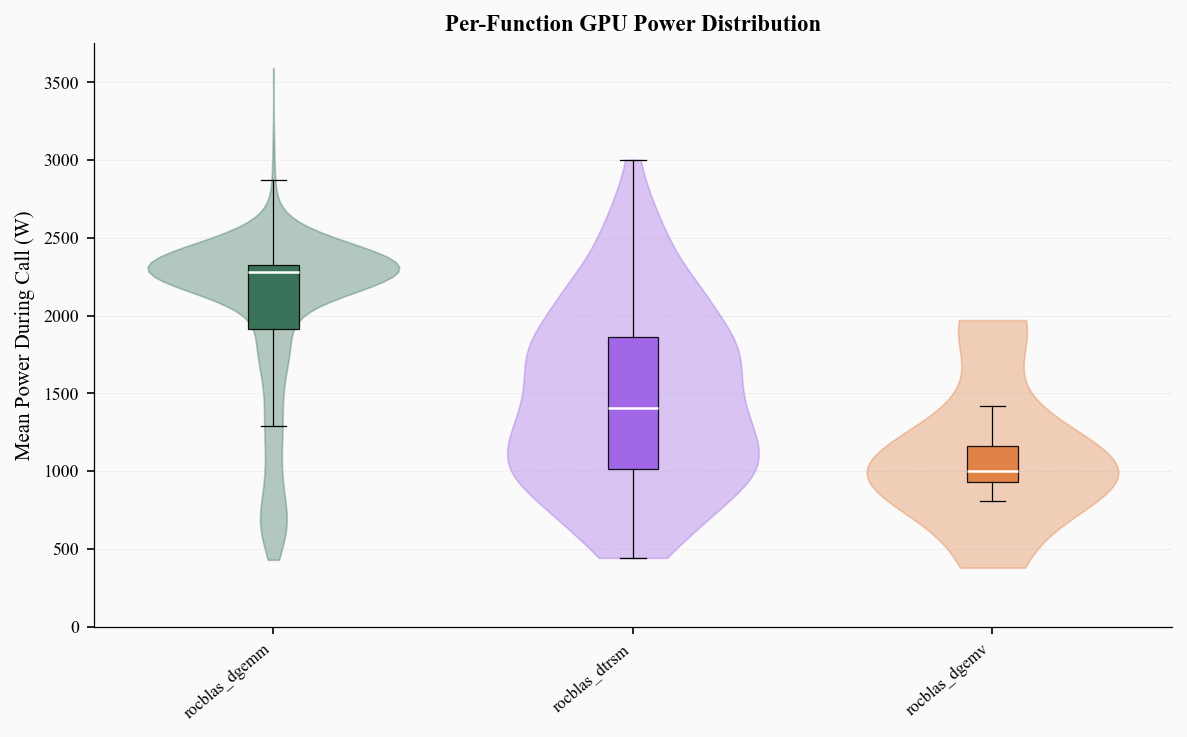

In [7]:
if not combined.empty and combined['PowerMean'].notna().any():
    # Keep functions with ≥ 10 power observations
    func_counts = combined.dropna(subset=['PowerMean'])['Short'].value_counts()
    funcs_plot  = func_counts[func_counts >= 10].index.tolist()

    data = {fn: combined[combined['Short'] == fn]['PowerMean'].dropna().values
            for fn in funcs_plot}
    funcs_plot = [fn for fn in funcs_plot if len(data[fn]) >= 10]
    funcs_plot.sort(key=lambda fn: np.median(data[fn]), reverse=True)

    fcolors = func_color_map(combined['Short'].unique())

    fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(funcs_plot)), 5), facecolor=BG)
    ax.set_facecolor(BG)

    positions = range(len(funcs_plot))
    for i, fn in enumerate(funcs_plot):
        vals = data[fn]
        color = fcolors.get(fn, '#888')

        vp = ax.violinplot(vals, positions=[i], showextrema=False, widths=0.7)
        for body in vp['bodies']:
            body.set_facecolor(color); body.set_alpha(0.35)
            body.set_edgecolor(color); body.set_linewidth(0.8)

        bp = ax.boxplot(vals, positions=[i], widths=0.14, patch_artist=True,
                        showfliers=False, zorder=3)
        bp['boxes'][0].set_facecolor(color); bp['boxes'][0].set_alpha(0.9)
        bp['boxes'][0].set_edgecolor('black'); bp['boxes'][0].set_linewidth(0.6)
        for el in ['whiskers', 'caps']:
            for line in bp[el]: line.set_color('black'); line.set_linewidth(0.6)
        bp['medians'][0].set_color('white'); bp['medians'][0].set_linewidth(1.2)

    ax.set_xticks(list(positions))
    ax.set_xticklabels(funcs_plot, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Mean Power During Call (W)')
    ax.set_title('Per-Function GPU Power Distribution', fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_ylim(0)

    fig.tight_layout()
    fig.savefig('fig3_function_power_violin.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 4: Top Trigrams by Peak Power

Which 3-call sequences drive the highest instantaneous power bursts?

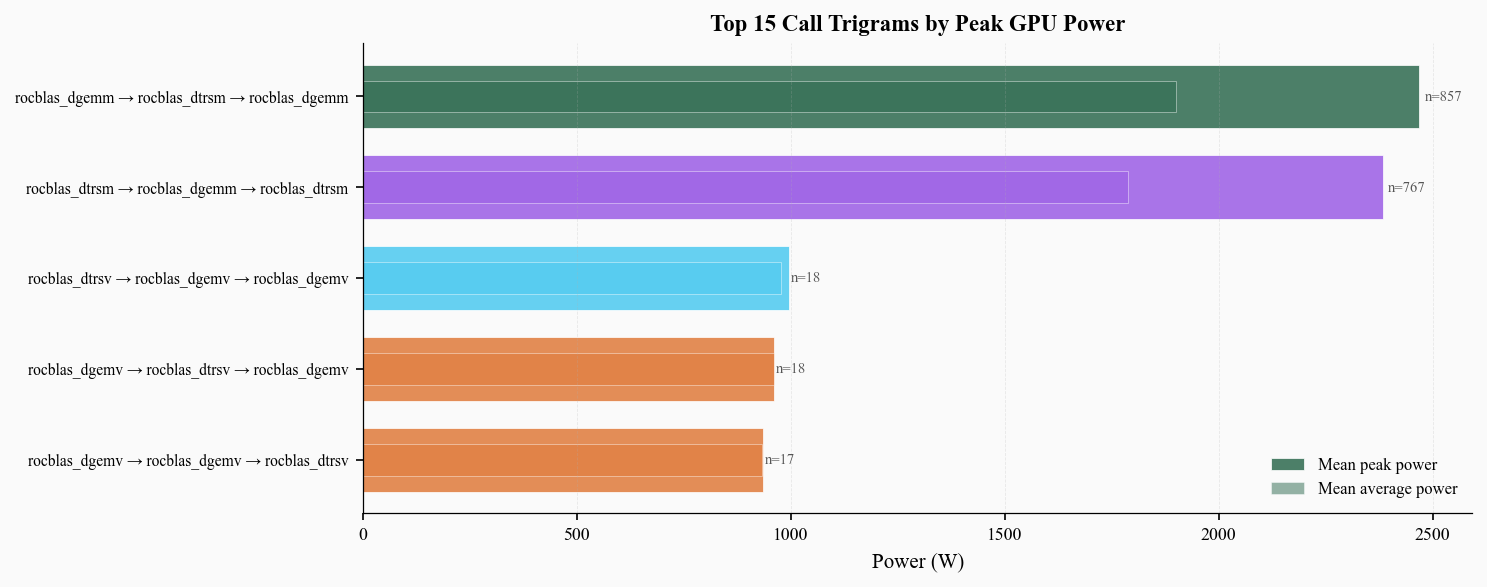

In [8]:
if not trigrams.empty:
    tg_stats = (trigrams.dropna(subset=['PowerPeak'])
                        .groupby('NGram')
                        .agg(mean_peak=('PowerPeak', 'mean'),
                             mean_avg=('PowerMean', 'mean'),
                             count=('NGram', 'size'))
                        .reset_index()
                        .query('count >= 3')
                        .sort_values('mean_peak', ascending=False)
                        .head(15))

    if tg_stats.empty:
        print("Not enough repeated trigrams for this plot.")
    else:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(tg_stats))), facecolor=BG)
        ax.set_facecolor(BG)

        fcolors = func_color_map(combined['Short'].unique())
        colors = [fcolors.get(row['NGram'].split(' → ')[0], '#888')
                  for _, row in tg_stats.iterrows()]

        ax.barh(range(len(tg_stats)), tg_stats['mean_peak'].values,
                color=colors, edgecolor='white', linewidth=0.4, height=0.7, alpha=0.85,
                label='Mean peak power')
        ax.barh(range(len(tg_stats)), tg_stats['mean_avg'].values,
                color=colors, edgecolor='white', linewidth=0.4, height=0.35,
                alpha=0.5, label='Mean average power')

        ax.set_yticks(range(len(tg_stats)))
        ax.set_yticklabels(tg_stats['NGram'].values, fontsize=7.5)
        ax.invert_yaxis()
        ax.set_xlabel('Power (W)')
        ax.set_title('Top 15 Call Trigrams by Peak GPU Power', fontweight='bold')
        ax.legend(frameon=False, fontsize=8)
        ax.grid(axis='x', alpha=0.25, linestyle='--')

        for i, (_, row) in enumerate(tg_stats.iterrows()):
            ax.text(row['mean_peak'] * 1.005, i,
                    f"n={row['count']:,}", va='center', fontsize=7, color='#555')

        fig.tight_layout()
        fig.savefig('fig4_trigram_peak_power.pdf', facecolor=BG, bbox_inches='tight')
        plt.show()


## Figure 5: Power Spike Alignment with Sequence Boundaries

For the benchmark's rank 0, overlay the power trace with markers at every BLAS call boundary.  
This visually confirms that power transitions are driven by function-sequence changes.

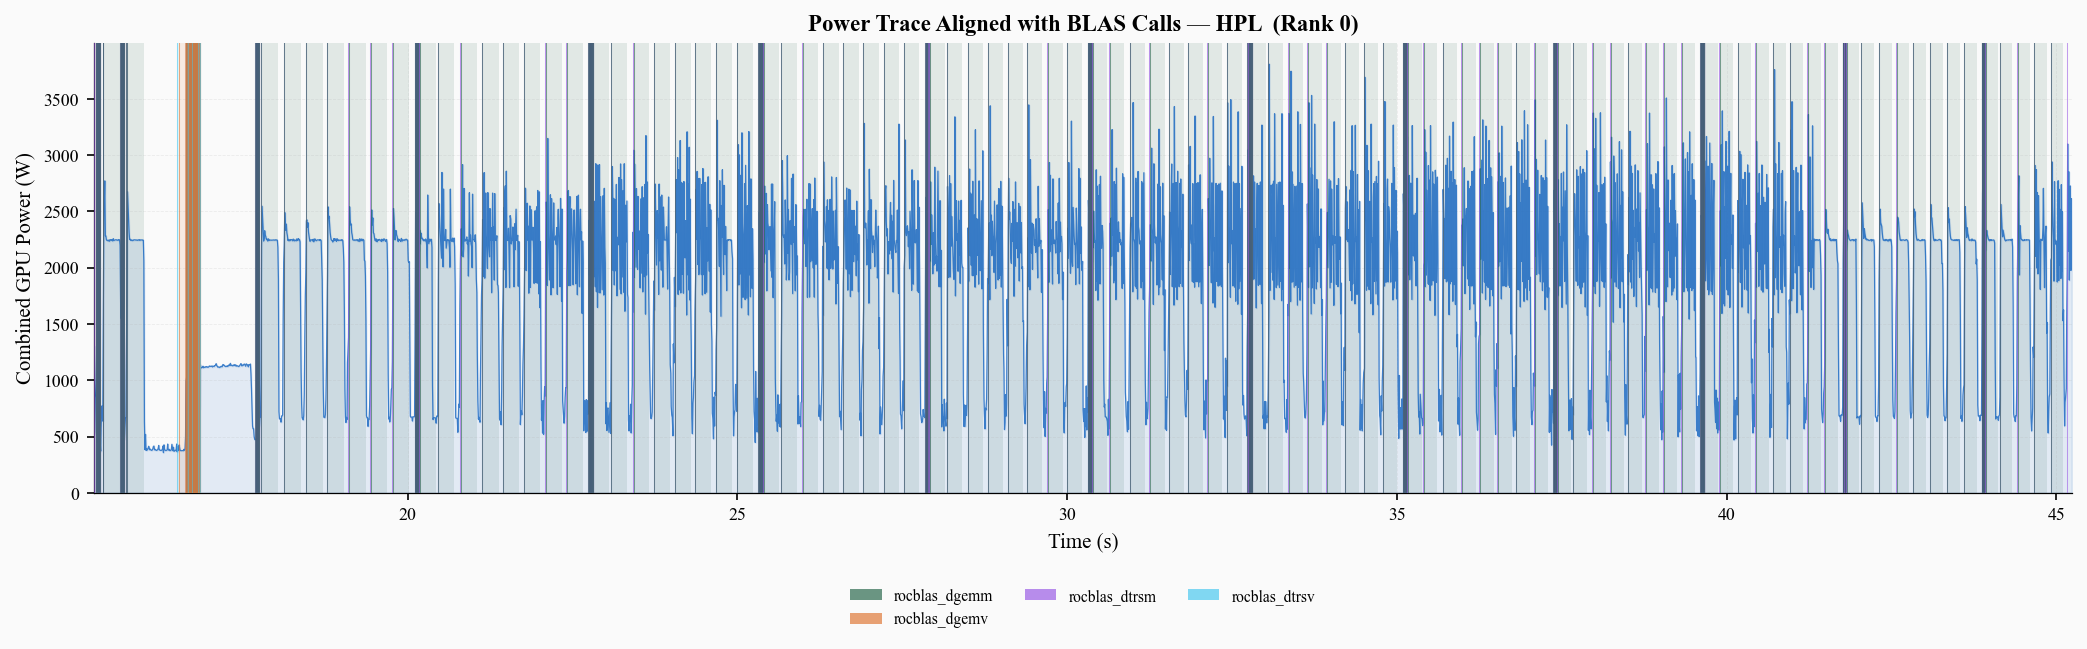

In [9]:
if all_calls:
    bench_name = list(all_calls.keys())[0]
    trial_path = BENCHMARKS[bench_name]
    m_path     = trial_path / "MPI Rank 0_metrics.csv"
    calls_r0   = all_calls[bench_name]
    calls_r0   = calls_r0[calls_r0['Rank'] == 0].sort_values('Start Time')

    if m_path.exists() and not calls_r0.empty:
        power_t, power_v = load_power_series(m_path)

        # Focus on a representative 30-second window in the compute phase
        t_start = calls_r0['Start Time'].min()
        t_end   = min(calls_r0['End Time'].max(), t_start + 30.0)
        pt_mask = (power_t >= t_start) & (power_t <= t_end)
        calls_win = calls_r0[(calls_r0['Start Time'] >= t_start) &
                              (calls_r0['End Time']   <= t_end)].copy()

        fcolors = func_color_map(combined['Short'].unique())

        fig, ax = plt.subplots(figsize=(14, 4.5), facecolor=BG)
        ax.set_facecolor(BG)

        # Power trace
        ax.plot(power_t[pt_mask], power_v[pt_mask],
                lw=0.6, color='#1565C0', alpha=0.8, zorder=2)
        ax.fill_between(power_t[pt_mask], power_v[pt_mask],
                        alpha=0.1, color='#1565C0', zorder=1)

        # Shade each call window by function type
        y_max = power_v[pt_mask].max() if power_v[pt_mask].size > 0 else 600
        for _, row in calls_win.iterrows():
            color = fcolors.get(row['Short'], '#888')
            ax.axvspan(row['Start Time'], row['End Time'],
                       alpha=0.12, color=color, linewidth=0, zorder=0)
            ax.axvline(row['Start Time'], color=color, lw=0.5, alpha=0.6, zorder=3)

        # Legend for unique functions in this window
        funcs_win = calls_win['Short'].unique()
        handles = [mpatches.Patch(facecolor=fcolors.get(fn, '#888'), label=fn, alpha=0.7)
                   for fn in sorted(funcs_win)]
        ax.legend(handles=handles, frameon=False, fontsize=7.5, ncol=3,
                  loc='upper center', bbox_to_anchor=(0.5, -0.18))

        ax.set_xlim(t_start, t_end)
        ax.set_ylim(0)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Combined GPU Power (W)')
        ax.set_title(f'Power Trace Aligned with BLAS Calls — {bench_name}  (Rank 0)',
                     fontweight='bold')
        ax.grid(alpha=0.2, linestyle='--')

        fig.tight_layout()
        fig.savefig(f'fig5_{bench_name}_power_alignment.pdf', facecolor=BG, bbox_inches='tight')
        plt.show()
    else:
        print("Metrics or call data not available for rank 0.")
